In [ ]:
!pip install xgboost

import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

ROC-AUC: 76.95%
Accuracy: 70.02%
Precision: 84.67%
Recall: 55.34%
F1 Score: 66.93%

Confusion Matrix:
 [[14325  1983]
 [ 8841 10955]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.88      0.73     16308
           1       0.85      0.55      0.67     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.72      0.70     36104
weighted avg       0.74      0.70      0.69     36104



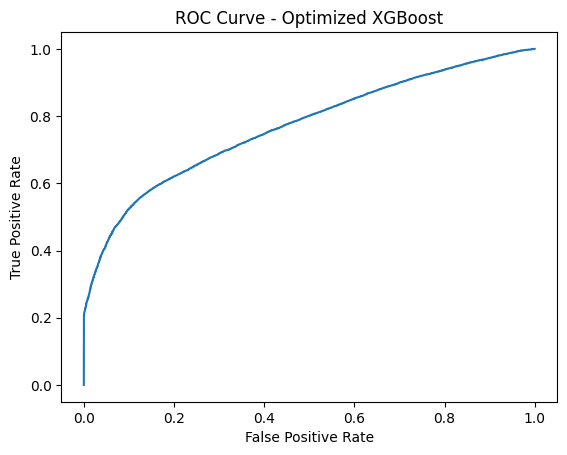

Model saved successfully as xgb_supply_chain_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from xgboost import XGBClassifier

df = pd.read_csv("data/raw/L_SCM_dataset.csv")

X = df.drop([
    'Late_delivery_risk',
    'Delivery Delay',
    'Days for shipping (real)'
], axis=1)

y = df['Late_delivery_risk']

X['urgency_ratio'] = X['Order Item Quantity'] / (X['Days for shipment (scheduled)'] + 1)
X['profit_margin'] = X['Order Profit Per Order'] / (X['Sales'] + 1)
X['discount_effect'] = X['Order Item Discount Rate'] * X['Sales']
X['price_per_quantity'] = X['Order Item Product Price'] / (X['Order Item Quantity'] + 1)
X['shipment_pressure'] = X['Days for shipment (scheduled)'] * X['Order Item Quantity']

for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category').cat.codes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=2
)

xgb.fit(X_train, y_train)

y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("ROC-AUC: {:.2f}%".format(roc_auc_score(y_test, y_prob)*100))
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred)*100))
print("Precision: {:.2f}%".format(precision_score(y_test, y_pred)*100))
print("Recall: {:.2f}%".format(recall_score(y_test, y_pred)*100))
print("F1 Score: {:.2f}%".format(f1_score(y_test, y_pred)*100))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized XGBoost")
plt.show()

os.makedirs("models", exist_ok=True)
joblib.dump(xgb, "models/xgb_supply_chain_model.pkl")
print("Model saved successfully at models/xgb_supply_chain_model.pkl")